In [6]:
from langgraph.graph import StateGraph,  START, END
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from typing import TypedDict

In [3]:
load_dotenv()

model = ChatGroq(
    model_name="llama-3.3-70b-versatile",
    temperature=0.7
)

In [5]:
class BlogState(TypedDict):
    topic: str
    outline: str
    blog: str

In [8]:
def generate_outline(state: BlogState):


    prompt = f"Generate Outline of this given topic {state['topic']}"
    state['outline'] = model.invoke(prompt).content

    return state

In [9]:
def generate_blog(state: BlogState):

    prompt = f"Generate blog of this given outline: {state['outline']}"
    state['blog'] = model.invoke(prompt).content

    return state

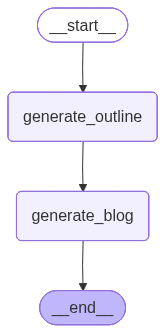

In [11]:
graph = StateGraph(BlogState)

graph.add_node('generate_outline', generate_outline)
graph.add_node('generate_blog', generate_blog)


graph.add_edge(START, 'generate_outline')
graph.add_edge('generate_outline', 'generate_blog')
graph.add_edge('generate_blog', END)

workflow = graph.compile()

workflow

In [13]:
initial_state = {'topic': 'Rise of AI in India'}
final_state = workflow.invoke(initial_state)
print(final_state)

{'topic': 'Rise of AI in India', 'outline': 'Here\'s a comprehensive outline on the topic "Rise of AI in India":\n\n**I. Introduction**\n  * Definition of Artificial Intelligence (AI)\n  * Brief overview of AI\'s global impact\n  * Importance of AI in India\'s growth and development\n\n**II. Current State of AI in India**\n  * Overview of India\'s AI ecosystem\n  * Key players in India\'s AI industry (startups, companies, research institutions)\n  * Current AI adoption rates in various sectors (e.g., healthcare, finance, education)\n\n**III. Drivers of AI Growth in India**\n  * Government initiatives and policies (e.g., National AI Strategy, AI Task Force)\n  * Increasing investments in AI research and development\n  * Growing demand for AI-powered solutions in various industries\n  * Availability of large datasets and computing power\n\n**IV. Applications of AI in India**\n  * Healthcare: AI in medical diagnosis, patient care, and medical research\n  * Finance: AI in banking, insuranc

In [15]:
final_state['outline']

'Here\'s a comprehensive outline on the topic "Rise of AI in India":\n\n**I. Introduction**\n  * Definition of Artificial Intelligence (AI)\n  * Brief overview of AI\'s global impact\n  * Importance of AI in India\'s growth and development\n\n**II. Current State of AI in India**\n  * Overview of India\'s AI ecosystem\n  * Key players in India\'s AI industry (startups, companies, research institutions)\n  * Current AI adoption rates in various sectors (e.g., healthcare, finance, education)\n\n**III. Drivers of AI Growth in India**\n  * Government initiatives and policies (e.g., National AI Strategy, AI Task Force)\n  * Increasing investments in AI research and development\n  * Growing demand for AI-powered solutions in various industries\n  * Availability of large datasets and computing power\n\n**IV. Applications of AI in India**\n  * Healthcare: AI in medical diagnosis, patient care, and medical research\n  * Finance: AI in banking, insurance, and financial services\n  * Education: AI

In [16]:
final_state['blog']

"**The Rise of AI in India: Unlocking the Future of Growth and Development**\n\n**Introduction**\n\nArtificial Intelligence (AI) has revolutionized the world, transforming the way we live, work, and interact with each other. As a rapidly growing technology, AI has been making waves globally, and India is no exception. With its vast talent pool, growing economy, and increasing adoption of digital technologies, India is poised to become a significant player in the global AI landscape. In this blog, we will explore the rise of AI in India, its current state, drivers of growth, applications, challenges, and future prospects.\n\n**Current State of AI in India**\n\nIndia's AI ecosystem is thriving, with a growing number of startups, companies, and research institutions actively working on AI-related projects. The country has witnessed a significant increase in AI adoption rates across various sectors, including healthcare, finance, education, and manufacturing. According to a recent report, 